#### OBJECTIVE
- Before we build massive MLOps orchestration, experimentation or fine-tune models using MLflow, we must empirically prove the business problem is computationally solvable. We will write a fast Python script to quickly train a naive Random Forest Regressor and evaluate it with our custom Weighted MAPE (where holiday weeks are mathematically penalized 5x). We must decidedly beat the 11.85% manual heuristic.

#### Result:
- Random Forest was taken as baseline algorithm and successfully with a good margin 
Model WMAPE: 0.0849
Target to Beat: 0.1185
- Random forest with no tuning and default settings in scikit learn yields WMAPE of 8.5%.
- The main features were the `sales_last_year` and `rolling_4wk_sales_avg`which were engineered before.
- This is because random forest is a greedy algorithm and it found these features to yield best splits and rest were used as residuals. 
- Other algorithms may balance it out.
#### Insights
- There are null values in the lagging features we created, we can either drop the columns or a year of data i.e for 2010 where lagging features are absent.
- But we NEVER drop sales_last_year, this feature already showed us in `baseline.ipynb` that it can alone get to wmae of around 12%. We always choose to drop the first year of data instead (the "warm-up" period).
- The `rolling_4_wk_sales_avg` tells the model the current "momentum" or "velocity" of sales right now, and `sales_last_year` tells the model the exact seasonal spike to expect.



In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
import pandas as pd
import numpy as np
import config
from sklearn.ensemble import RandomForestRegressor

In [ ]:
pd.set_option('display.max_columns', 22)

In [ ]:
master_df = pd.read_parquet(config.GOLD_MASTER_PATH)

master_df.head()

,store,dept,date,weekly_sales,isholiday,store_type,store_size,temperature,fuel_price,cpi,unemployment,markdown1,markdown2,markdown3,markdown4,markdown5,total_markdown,month,week_of_year,rolling_4_wk_sales_avg,sales_last_year,cpi_lag_3_month
0,1,1,2010-02-05,24924.50,False,A,151315,42.31,2.572,211.096359,8.106,0.0,0.0,0.0,0.0,0.0,0.0,2,5,NaN,NaN,211.096359
1,1,2,2010-02-05,50605.27,False,A,151315,42.31,2.572,211.096359,8.106,0.0,0.0,0.0,0.0,0.0,0.0,2,5,NaN,NaN,211.096359
2,1,3,2010-02-05,13740.12,False,A,151315,42.31,2.572,211.096359,8.106,0.0,0.0,0.0,0.0,0.0,0.0,2,5,NaN,NaN,211.096359
3,1,4,2010-02-05,39954.04,False,A,151315,42.31,2.572,211.096359,8.106,0.0,0.0,0.0,0.0,0.0,0.0,2,5,NaN,NaN,211.096359
4,1,5,2010-02-05,32229.38,False,A,151315,42.31,2.572,211.096359,8.106,0.0,0.0,0.0,0.0,0.0,0.0,2,5,NaN,NaN,NaN


In [ ]:
master_df = master_df.dropna()
master_df.head()

,store,dept,date,weekly_sales,isholiday,store_type,store_size,temperature,fuel_price,cpi,unemployment,markdown1,markdown2,markdown3,markdown4,markdown5,total_markdown,month,week_of_year,rolling_4_wk_sales_avg,sales_last_year,cpi_lag_3_month
152374,1,1,2011-02-04,21665.76,False,A,151315,42.27,2.989,212.566879,7.742,0.0,0.0,0.0,0.0,0.0,0.0,2,5,17286.6475,24924.50,212.566879
152375,1,2,2011-02-04,46829.12,False,A,151315,42.27,2.989,212.566879,7.742,0.0,0.0,0.0,0.0,0.0,0.0,2,5,41576.9225,50605.27,212.566879
152376,1,3,2011-02-04,11012.52,False,A,151315,42.27,2.989,212.566879,7.742,0.0,0.0,0.0,0.0,0.0,0.0,2,5,13400.0750,13740.12,212.566879
152377,1,4,2011-02-04,35870.49,False,A,151315,42.27,2.989,212.566879,7.742,0.0,0.0,0.0,0.0,0.0,0.0,2,5,34745.8025,39954.04,212.566879
152378,1,5,2011-02-04,31280.62,False,A,151315,42.27,2.989,212.566879,7.742,0.0,0.0,0.0,0.0,0.0,0.0,2,5,20175.4575,32229.38,212.197052


We will do a chronological split to avoid lookahead bias, we will do a simple 80:20 split for train and test set, we dont need validation set as we are not tuning yet.

In [ ]:
df = master_df
split_date = df['date'].quantile(0.8)

datetime.date(2012, 6, 29)

In [ ]:
features = [
    'store', 'dept', 'isholiday', 'store_size', 'temperature', 
    'fuel_price', 'cpi', 'unemployment', 'total_markdown', 
    'month', 'week_of_year', 'rolling_4_wk_sales_avg', 'sales_last_year', 'cpi_lag_3_month'
]
target = 'weekly_sales'

In [ ]:

train = df[df['date'] < split_date]
test = df[df['date'] >= split_date]
X_train, y_train = train[features], train[target]
X_test, y_test = test[features], test[target]

print(f"Train rows: {len(train)} | Test rows: {len(test)} | Split Date: {split_date}")

Train rows: 208774 | Test rows: 52309 | Split Date: 2012-06-29


In [ ]:
model = RandomForestRegressor(n_estimators=100, max_depth=15, n_jobs=-1, random_state=42 )
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [ ]:
def wmape_metric(y_true, y_pred, is_holiday):
    # Holiday mistakes cost the business 5x more due to stockouts
    weights = np.where(is_holiday==1, 5, 1)

    return np.sum(weights*np.abs(y_true - y_pred)) / np.sum(weights * y_true)
    

In [ ]:
# Predict & Evaluate
preds = model.predict(X_test)
error_wmape = wmape_metric(y_test.values, preds, test['isholiday'].values)
print(f"Model WMAPE: {round(error_wmape, 4)}")
print(f"Target to Beat: 0.1185")
if error_wmape < 0.1185:
    print("✅ FEASIBILITY PASSED! We structurally beat the baseline! We have a Go-Decision!")
else:
    print("❌ FEASIBILITY FAILED! We did not beat the baseline. Stop MLOps investment.")

Model WMAPE: 0.0849
Target to Beat: 0.1185
✅ FEASIBILITY PASSED! We structurally beat the baseline! We have a Go-Decision!


,Feature,Importance
12,sales_last_year,0.859908
11,rolling_4_wk_sales_avg,0.124702
1,dept,0.002874
10,week_of_year,0.002340
5,fuel_price,0.001557
8,total_markdown,0.001455
7,unemployment,0.001323
3,store_size,0.001211
4,temperature,0.001182
0,store,0.000923


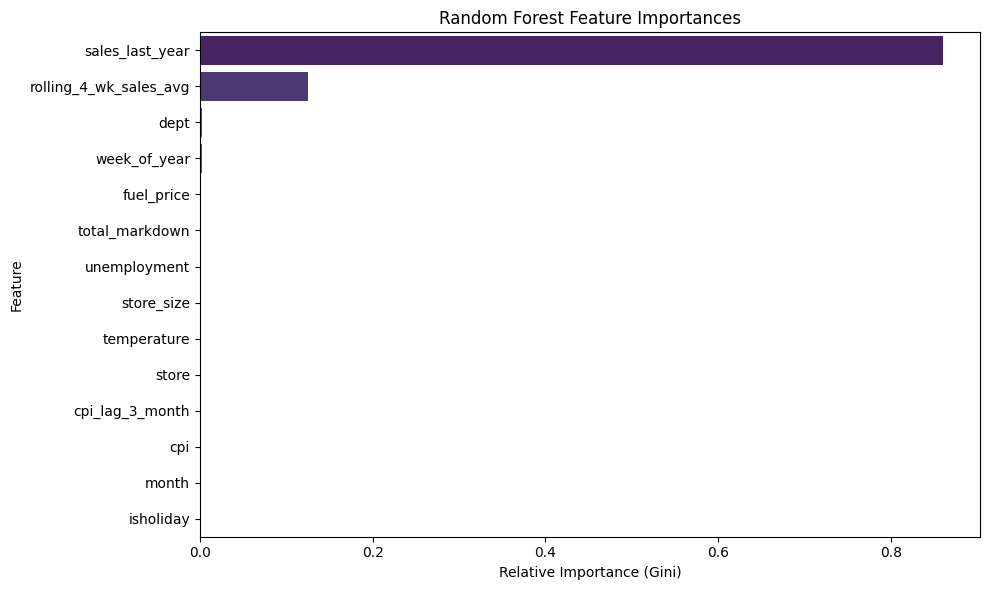

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extract importances from the trained model
importances = model.feature_importances_

# Map them to our feature names and sort them
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Display the exact numbers
display(importance_df)

# Plot them visually
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, hue='Feature', palette='viridis', legend=False)
plt.title('Random Forest Feature Importances')
plt.xlabel('Relative Importance (Gini)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()
